# Nama: I Made Bimantoro Mastra

---


# Assignment: Day 7 - Descriptive Statistic

---



## A. Dataset Dummy — konfigurasi & generator generik

In [ ]:
!pip install faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from faker import Faker
import random
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Seed supaya hasil random konsisten setiap kali dijalankan (reproducible)
random.seed(42)
np.random.seed(42)
Faker.seed(42)
fake = Faker('id_ID') # locale Indonesia -> nama, email, no telepon bergaya Indonesia

N_ROWS = 100  # Untuk mengatur jumlah baris

### Logika pembuatan tiap kolom

- **Nama_Lokasi**: digabung acak dari jenis tempat (Kampus/Mall/Cafe/dst) + kode (A/B/C/X/Y/Z).
- **Jam_Login**: angka bulat 6–23(jam operasional wajar)
- **Tahun_Lahir**: 1980–2010 sesuai instruksi soal.
- **Merk_HP**: 5 merk populer, probabilitas dibuat tidak rata (Samsung & iPhone sedikit lebih dominan) supaya lebih realistis.
- **Minat_Digital**: skor 1–10.
- **Tipe_Lokasi**: 4 kategori sesuai instruksi.
- **Frekuensi_Login_per_Minggu**: 1–14 (maks 2x sehari selama seminggu).
- **Durasi_Login_menit**: 15–240 menit per sesi.
- **Pengeluaran_Digital_per_Bulan**: Rp100.000–Rp3.000.000.
- **Status**: kategorik: "Mahasiswa", "Pekerja", "Lainnya.
- **Jenis_Kelamin**: "Laki-laki", "Perempuan

**Variabel pengembangan (turunan, bukan random murni — dihitung dari kolom lain):**
- **Usia** = 2024 − Tahun_Lahir
- **Rata_Durasi_per_Sesi** = Durasi_Login_menit ÷ Frekuensi_Login_per_Minggu (rata-rata menit per sesi login)
- **Tingkat_Ketergantungan_Digital** (1–5) = Semakin tinggi minat & makin sering login, semakin tinggi skor ketergantungan (di-clip ke rentang 1–5).

In [ ]:
# Variabel kategorik: nama_kolom -> (list_pilihan, list_probabilitas atau None untuk uniform)
CATEGORICAL_CONFIG = {
    'Merk_HP': (['Samsung', 'iPhone', 'Oppo', 'Vivo', 'Xiaomi'], [0.25, 0.20, 0.20, 0.20, 0.15]),
    'Tipe_Lokasi': (['Public', 'Private', 'Coworking', 'Campus'], None),
    'Status': (['Mahasiswa', 'Pekerja', 'Lainnya'], [0.6, 0.3, 0.1]),
    'Jenis_Kelamin': (['Laki-laki', 'Perempuan'], None),
}

# Variabel numerik: nama_kolom -> (low, high) -> di-generate dengan randint(low, high+1)
NUMERIC_CONFIG = {                #Range angka dari yang terendah hingga tertinggi untuk di generate
    'Jam_Login': (6, 23),
    'Tahun_Lahir': (1980, 2010), # Supaya bisa mencangkup 2010 harus menggunakan high+1
    'Minat_Digital': (1, 10), # Supaya bisa mencangkup 10 harus menggunakan high+1
    'Frekuensi_Login_per_Minggu': (1, 14),
    'Durasi_Login_menit': (15, 240),
    'Pengeluaran_Digital_per_Bulan': (100000, 3000000),
}

LOKASI_PREFIX = ['Kampus', 'Mall', 'Cafe', 'Coworking Space', 'Perpustakaan']
LOKASI_KODE = ['A', 'B', 'C', 'X', 'Y', 'Z']

In [ ]:
def generate_categorical(config, n):
    """Generate semua kolom kategorik dari config, return dict {nama_kolom: array}."""
    result = {}
    for col, (choices, probs) in config.items():    # Mengambil key dan value yang ada di config.items, tetapi value dipecah menjadi variable choices dan probs.
        result[col] = np.random.choice(choices, size=n, p=probs)
    return result                                    # Fungsi for loop semua kolom kategorik yang ada di config tanpa perlu diketik satu satu.

def generate_numeric(config, n):
    """Generate semua kolom numerik dari config (integer uniform low-high), return dict {nama_kolom: array}."""
    result = {}
    for col, (low, high) in config.items():          # Mengambil key dan value yang ada di config.items, tetapi value dipecah menjadi variable low dan high.
        result[col] = np.random.randint(low, high + 1, size=n)
    return result                                    # Fungsi for loop semua kolom numerik yang ada di config tanpa perlu diketik satu satu.

def generate_identity(n):
    return {                                         # Menggenarate value random dari 3 key mengunakan faker.
        'Nama': [fake.name() for _ in range(n)],
        'Email': [fake.email() for _ in range(n)],
        'No_Telepon': [fake.phone_number() for _ in range(n)],
    }

def generate_lokasi(n):
    return [f"{random.choice(LOKASI_PREFIX)} {random.choice(LOKASI_KODE)}" for _ in range(n)] # Mengrandom pilihan yang ada di lokasi_prefix dan lokasi_kode, kemudian diulang n kali.

In [ ]:
# --- Bangun dataset dengan memanggil fungsi generator ---
data = {}                                                       # Siapkan dictionary kosong, ini akan jadi "wadah besar" semua kolom.
data.update(generate_identity(N_ROWS))                          # Menambahkan semua key-value dari dictionary lain ke dictionary ini.
data['Nama_Lokasi'] = generate_lokasi(N_ROWS)                   # Karna hasil generate_lokasi itu list jadi harus assign ke key baru Nama_Lokasi.
data.update(generate_numeric(NUMERIC_CONFIG, N_ROWS))           # Gabungkan semua kolom numerik ke data.
data.update(generate_categorical(CATEGORICAL_CONFIG, N_ROWS))   # Gabungkan semua kolom kategorik ke data.

df = pd.DataFrame(data)                                         # Mengubah semua data menjadi tabel pandas(DataFrame).

# Semua fungsi harus dikumpulkan dulu semua ke data sebelum dijadikan tabel.

# --- Variabel pengembangan/turunan (tetap eksplisit karena punya logika masing-masing) ---
df['Usia'] = 2024 - df['Tahun_Lahir']                                                     # Kolom baru 'Usia', dihitung dari jarak 'Tahun_Lahir' sampai 2024. Pandas otomatis menghitung ini untuk semua baris sekaligus.
df['Rata_Durasi_per_Sesi'] = df['Durasi_Login_menit'] / df['Frekuensi_Login_per_Minggu']  # Durasi_Login dibagi Frekuensi_Login menghasilkan rata-rata menit per satu kali login.
df['Tingkat_Ketergantungan_Digital'] = np.clip(
    np.round((df['Minat_Digital'] / 2 + df['Frekuensi_Login_per_Minggu'] / 3) / 2), 1, 5  # Tingkat_Ketergantungan berdasarkan rata rata Minat_Digital + Frekuensi_Login.
)                                                                                         # Minat_Digital dengan rentan 1-10 dan Frekuensi_Login dengan rentan 1-14 dibagi dengan 2 dan 3 seimbang diantara 0-5 berdasarkan Tingkat_Ketergantungan. np.round untuk membulatkan hasil dan np.clip 1,5 itu untuk membatasi hasil sesuai intruksi.

df.to_csv('dataset_dummy.csv', index=False)                     # Mengubah DataFrame menjadi CSV dengan nama dataset_dummy.csv. Menggunakan index=false supaya menghapus kolom numerik, jika tidak pandas akan membaca angka index dianggap sebagai kolom data biasa bernama Unnamed: 0.
print("Jumlah baris, kolom:", df.shape)                         # df.shape menampilkan (jumlah baris, jumlah kolom) dari tabel.
df.head()                                                       # Menampilkan 5 baris pertama dari tabel.

Jumlah baris, kolom: (100, 17)


,Nama,Email,No_Telepon,Nama_Lokasi,Jam_Login,Tahun_Lahir,Minat_Digital,Frekuensi_Login_per_Minggu,Durasi_Login_menit,Pengeluaran_Digital_per_Bulan,Merk_HP,Tipe_Lokasi,Status,Jenis_Kelamin,Usia,Rata_Durasi_per_Sesi,Tingkat_Ketergantungan_Digital
0,"Balidin Dongoran, S.T.",hardiansyahlaila@example.com,(057) 262-8498,Kampus A,12,1994,5,8,79,109435,Samsung,Public,Mahasiswa,Perempuan,30,9.875000,3.0
1,Darmana Mandala,balijanmelani@example.org,(0769) 453-1473,Cafe B,20,1993,1,7,22,547556,Samsung,Private,Mahasiswa,Laki-laki,31,3.142857,1.0
2,"Ciaobella Wastuti, M.Pd",cahyoriyanti@example.org,(0996) 507 5273,Mall B,16,1982,8,3,158,1848014,Xiaomi,Coworking,Mahasiswa,Laki-laki,42,52.666667,2.0
3,Lantar Anggraini,respatilazuardi@example.net,+62 (454) 948-0831,Kampus Z,13,1980,1,1,156,178781,Vivo,Public,Pekerja,Perempuan,44,156.000000,1.0
4,Among Iswahyudi,kiandrariyanti@example.org,+62-0678-377-7014,Perpustakaan A,12,1984,1,1,218,2388627,iPhone,Private,Pekerja,Perempuan,40,218.000000,1.0


## B.a. Data Preparation — cek struktur

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Nama                            100 non-null    object 
 1   Email                           100 non-null    object 
 2   No_Telepon                      100 non-null    object 
 3   Nama_Lokasi                     100 non-null    object 
 4   Jam_Login                       100 non-null    int64  
 5   Tahun_Lahir                     100 non-null    int64  
 6   Minat_Digital                   100 non-null    int64  
 7   Frekuensi_Login_per_Minggu      100 non-null    int64  
 8   Durasi_Login_menit              100 non-null    int64  
 9   Pengeluaran_Digital_per_Bulan   100 non-null    int64  
 10  Merk_HP                         100 non-null    object 
 11  Tipe_Lokasi                     100 non-null    object 
 12  Status                          100 n

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Nama,100,100,"Balidin Dongoran, S.T.",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email,100,100,hardiansyahlaila@example.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_Telepon,100,100,(057) 262-8498,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nama_Lokasi,100,28,Kampus A,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jam_Login,100.0,NaN,NaN,NaN,14.0,5.095056,6.0,9.0,13.5,18.0,23.0
Tahun_Lahir,100.0,NaN,NaN,NaN,1995.89,9.4076,1980.0,1988.0,1996.0,2005.0,2010.0
Minat_Digital,100.0,NaN,NaN,NaN,4.9,2.826641,1.0,2.75,4.0,7.25,10.0
Frekuensi_Login_per_Minggu,100.0,NaN,NaN,NaN,7.26,4.227424,1.0,3.0,7.0,11.0,14.0
Durasi_Login_menit,100.0,NaN,NaN,NaN,121.78,60.210335,15.0,72.0,121.0,161.75,239.0
Pengeluaran_Digital_per_Bulan,100.0,NaN,NaN,NaN,1502119.85,915349.133787,103267.0,698300.5,1454113.0,2351078.0,2973817.0


## B.b. Eksplorasi Data & Statistik Deskriptif — fungsi generik + loop

Membuat satu fungsi `descriptive_stats()`
lalu di-loop untuk semua kolom yang diminta.

In [ ]:
def descriptive_stats(data):
    """Hitung mean, median, mode, variance, std, range untuk satu Series numerik."""
    return {
        'mean': data.mean(),                # Rata-rata (jumlah semua nilai dibagi jumlah data).
        'median': data.median(),            # Nilai tengah setelah data diurutkan.
        'mode': data.mode().iloc[0],        # Mengembalikan nilai yang paling sering muncul. ,iloc[0] mengambil nilai pertama saja supaya hasilnya satu angka tunggal.
        'variance': data.var(),             # Menghitung variance (ukuran penyebaran data terhadap mean, dalam satuan kuadrat).
        'std': data.std(),                  # Menghitung standard deviation (akar dari variance, satuan sama dengan data asli).
        'range': data.max() - data.min(),   # Selisih nilai terbesar dan terkecil di data.
    }

NUMERIC_COLS_FOR_STATS = ['Usia', 'Minat_Digital', 'Frekuensi_Login_per_Minggu',                    # Daftar data numerik yang akan dipakai
                           'Durasi_Login_menit', 'Pengeluaran_Digital_per_Bulan', 'Jam_Login']

stats_summary = pd.DataFrame({col: descriptive_stats(df[col]) for col in NUMERIC_COLS_FOR_STATS}).T # .T transpose membalik key diluar menjadi baris dan key didalam menjadi kolom untuk mengakali default dari pandas.
stats_summary

,mean,median,mode,variance,std,range
Usia,28.11,28.0,15.0,8.850293e+01,9.407600,30.0
Minat_Digital,4.90,4.0,1.0,7.989899e+00,2.826641,9.0
Frekuensi_Login_per_Minggu,7.26,7.0,1.0,1.787111e+01,4.227424,13.0
Durasi_Login_menit,121.78,121.0,72.0,3.625284e+03,60.210335,224.0
Pengeluaran_Digital_per_Bulan,1502119.85,1454113.0,103267.0,8.378640e+11,915349.133787,2870550.0
Jam_Login,14.00,13.5,13.0,2.595960e+01,5.095056,17.0


## B.c. Analisis Hubungan Variabel

Hitung **covariance** dan **correlation** antara minimal dua variabel numerik. Apakah ada hubungan positif/negatif? Apakah kuat hubungannya atau tidak?




In [ ]:
PAIRS = [                                                             # List baru yang berisi 3 Tuple. Tiap tuple berisi 2 nama kolom ('Usia', 'Minat_Digital').
    ('Usia', 'Minat_Digital'),
    ('Pengeluaran_Digital_per_Bulan', 'Frekuensi_Login_per_Minggu'),
    ('Minat_Digital', 'Durasi_Login_menit'),
]

# Covariance: mengukur apakah dua variabel bergerak searah atau berlawanan arah. Tapi angkanya susah diinterpretasi langsung, karena tergantung skala/satuan datanya.
# Correlation: Pengukuran kekuatan hubungannya antara -1 sampai 1.  Mendekati 1 = hubungan positif kuat, mendekati -1 = hubungan negatif kuat, mendekati 0 = hampir tidak ada hubungan.

def cov_corr(df, col_a, col_b):                 # Fungsi untuk menerima 3 hal: df (tabel data lengkap), col_a dan col_b yang mau dibandingkan.
    cov = df[[col_a, col_b]].cov().iloc[0, 1]   # 2 kurung siku karna cov dan corr butuh minimal 2 kolom dan bukan hanya 1 ([]) yang hasilnya akan menjadi series.
    corr = df[[col_a, col_b]].corr().iloc[0, 1] # iloc[0,1] angka diagonal.
    return cov, corr                            # Fungsi mengembalikan dua nilai sekaligus: angka covariance dan angka correlation.

results = []
for a, b in PAIRS:
    cov, corr = cov_corr(df, a, b)
    results.append({'Variabel_1': a, 'Variabel_2': b, 'Covariance': cov, 'Correlation': corr})

# Menentukan apakah hubungan kuat/ tidak
def interpretasi_korelasi(corr):
    arah = "positif" if corr > 0 else "negatif" if corr < 0 else "tidak ada arah"
    kekuatan_abs = abs(corr)
    if kekuatan_abs >= 0.7:
        kekuatan = "kuat"
    elif kekuatan_abs >= 0.3:
        kekuatan = "sedang"
    else:
        kekuatan = "lemah"
    return f"Hubungan {arah}, kekuatan {kekuatan} (r = {corr:.2f})"

for r in results:
    r['Interpretasi'] = interpretasi_korelasi(r['Correlation'])

pd.DataFrame(results)

,Variabel_1,Variabel_2,Covariance,Correlation,Interpretasi
0,Usia,Minat_Digital,-4.221212,-0.158740,"Hubungan negatif, kekuatan lemah (r = -0.16)"
1,Pengeluaran_Digital_per_Bulan,Frekuensi_Login_per_Minggu,550284.110101,0.142208,"Hubungan positif, kekuatan lemah (r = 0.14)"
2,Minat_Digital,Durasi_Login_menit,14.260606,0.083791,"Hubungan positif, kekuatan lemah (r = 0.08)"


## B.d. Expected Value & Confidence Interval

In [ ]:
def expected_value(data):
    """Hitung expected value = sum(x * P(x)) dari distribusi probabilitas nilai diskrit."""
    prob = data.value_counts(normalize=True).sort_index()     # Menghitung berapa kali tiap nilai unik muncul, ubah dari hitungan jumlah jadi proporsi/peluang.
    return (prob.index.to_numpy() * prob.values).sum(), prob  # Ubah menjadi array numpy supaya mudah dihitung dari peluang p(x). E(X) = Σ [x × P(x)]

def confidence_interval_mean(data, confidence=0.95):
    """Hitung confidence interval untuk mean populasi berdasarkan sampel."""
    n = len(data)                                                             # Menghitung berapa banyak data di kolom
    mean_ = data.mean()                                                       # Menghitung mean dari data, diberi nama mean_ dengan garis bawah di belakang, supaya tidak bentrok dengan fungsi bawaan Python mean.
    sem_ = stats.sem(data)                                                    # Standard Error of the Mean: standard deviation dari sampel dibagi akar dari jumlah data di sampel.
    low, high = stats.t.interval(confidence, df=n - 1, loc=mean_, scale=sem_) # Mengembalikan dua angka: batas bawah (low) dan batas atas (high) dari interval.
    return mean_, (low, high)                                                 # Fungsi mengembalikan mean sampel, dan sepasang angka (batas bawah, batas atas) sebagai satu tuple.

ev_minat, prob_minat = expected_value(df['Minat_Digital'])    # Mengambil kolom Minat_Digital dari tabel df, kirim sebagai argumen ke fungsi expected_value.
print(f"Expected Value (Minat Digital) = {ev_minat:.3f}")     # F-string. Sisipkan nilai ev_minat, diformat jadi 3 angka di belakang koma

mean_usia, ci_usia = confidence_interval_mean(df['Usia'])                             # Confidence Interval.
print(f"Mean Usia = {mean_usia:.2f}, 95% CI = ({ci_usia[0]:.2f}, {ci_usia[1]:.2f})")  # Menangkap tuple (low[0], high[1]), format 2 angka di belakang koma.

# Expected value: menghitung nilai rata-rata yang diharapkan untuk mengundi/mengambil satu data secara acak dari distribusi yang ada dipengaruhi seberapa sering tiap nilai muncul.

Expected Value (Minat Digital) = 4.900
Mean Usia = 28.11, 95% CI = (26.24, 29.98)


## B.e. Segmentasi & Visualisasi

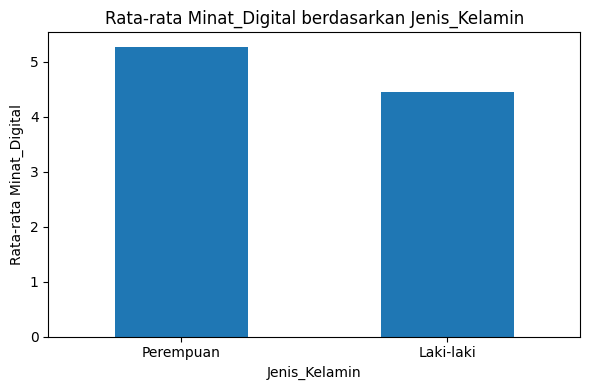

Jenis_Kelamin
Perempuan    5.272727
Laki-laki    4.444444
Name: Minat_Digital, dtype: float64


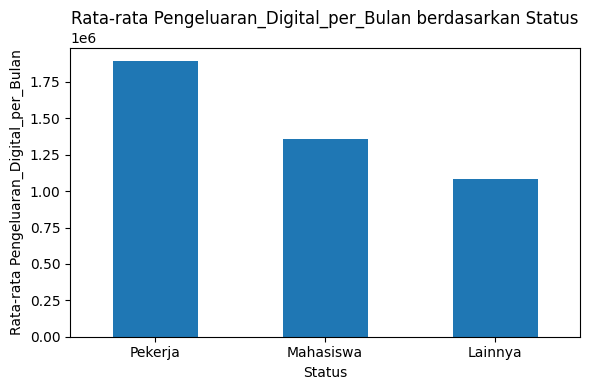

Status
Pekerja      1.892320e+06
Mahasiswa    1.358525e+06
Lainnya      1.082794e+06
Name: Pengeluaran_Digital_per_Bulan, dtype: float64


In [ ]:
def segment_mean(df, cat_col, num_col):                                      # Menghitung rata-rata per kelompok.
    """Hitung rata-rata num_col dikelompokkan berdasarkan cat_col."""
    return df.groupby(cat_col)[num_col].mean().sort_values(ascending=False)  # Kelompokkan baris berdasarkan nilai unik di kolom kategorikal. Hitung rata-rata kolom numerik. Urutkan hasil dari rata-rata tertinggi ke terendah

def plot_segment_bar(df, cat_col, num_col):                   # Fungsi menerima 3 hal: tabel data lengkap(df), nama kolom kategorikal(cat_col), dan nama kolom angka(num_col).
    seg = segment_mean(df, cat_col, num_col)                  # Panggil fungsi yang sudah dibuat di Bagian 1, dapatkan hasil rata-rata per grup.
    plt.figure(figsize=(6,4))                                 # Siapkan "kanvas" gambar kosong ukuran 6×4.
    seg.plot(kind='bar')                                      # Gambar segment sebagai bar chart.
    plt.title(f'Rata-rata {num_col} berdasarkan {cat_col}')   # Memberi judul grafik, otomatis menyesuaikan nama kolom yang sedang dianalisis.
    plt.ylabel(f'Rata-rata {num_col}')                        # beri label sumbu Y (vertikal), juga otomatis menyesuaikan.
    plt.xticks(rotation=0)                                    # Atur label di sumbu X, rotation=0 supaya tidak dimiringkan.
    plt.tight_layout()                                        # Rapikan jarak antar elemen grafik, supaya judul/label tidak terpotong atau bertabrakan.
    plt.show()                                                # Tampilkan grafik.
    return seg                                                # Fungsi juga mengembalikan data mentahnya (angka rata-rata per grup), supaya bisa dipakai/dilihat lagi di luar fungsi.

SEGMENTS_TO_ANALYZE = [
    ('Jenis_Kelamin', 'Minat_Digital'),
    ('Status', 'Pengeluaran_Digital_per_Bulan'),
]

for cat_col, num_col, in SEGMENTS_TO_ANALYZE:     # loop tiap tuple di SEGMENTS_TO_ANALYZE.
    seg = plot_segment_bar(df, cat_col, num_col)  # Iterasi 1: cat_col = 'Jenis_Kelamin', num_col = 'Minat_Digital', Iterasi 2: cat_col = 'Status', num_col = 'Pengeluaran_Digital_per_Bulan'.
    print(seg)                                    # Cetak data rata-rata per grup.

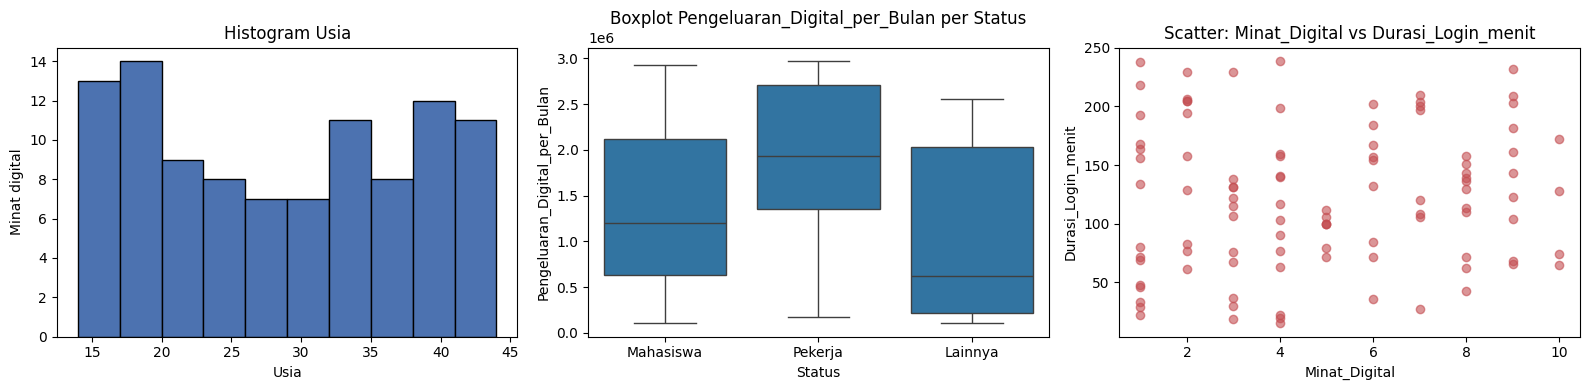

In [ ]:
# --- Visualisasi tambahan generik: histogram, boxplot, scatter ---
def plot_overview(df, hist_col, box_cat, box_num, scatter_x, scatter_y):     # Nama kolom untuk histogram, nama kolom kategori untuk boxplot, nama kolom angka,  nama kolom untuk sumbu X dan Y scatter plot.
    fig, axes = plt.subplots(1, 3, figsize=(16,4))                           # buat susunan 1 baris, 3 kolom menggunakan subplots dengan ukuran keseluruhan gambar besar itu, 16 inci lebar, 4 inci tinggi.
    axes[0].hist(df[hist_col], bins=10, color='#4C72B0', edgecolor='black')
    axes[0].set_xlabel(hist_col)
    axes[0].set_ylabel('Minat digital')
    axes[0].set_title(f'Histogram {hist_col}')                               # Beri judul di atas kotak pertama, otomatis menyesuaikan nama kolom lewat f-string.

    sns.boxplot(x=box_cat, y=box_num, data=df, ax=axes[1])                   # Sumbu X dengan kategorikal dan sumbu Y dengan numerik
    axes[1].set_title(f'Boxplot {box_num} per {box_cat}')                    # Beri judul di atas kotak pertama, otomatis menyesuaikan nama kolom lewat f-string.

    axes[2].scatter(df[scatter_x], df[scatter_y], alpha=0.6, color='#C44E52')# gambar scatter plot di kotak ketiga dengan data untuk sumbu X (misal Minat_Digital)  dan data untuk sumbu Y (misal Durasi_Login_menit).
    axes[2].set_xlabel(scatter_x)                                            # beri label sumbu X, otomatis pakai nama kolomnya.
    axes[2].set_ylabel(scatter_y)                                            # beri label sumbu Y, otomatis pakai nama kolomnya.
    axes[2].set_title(f'Scatter: {scatter_x} vs {scatter_y}')                # Beri judul di atas kotak pertama, otomatis menyesuaikan nama kolom lewat f-string.


    plt.show()

plot_overview(df, hist_col='Usia', box_cat='Status', box_num='Pengeluaran_Digital_per_Bulan', # hist_col → harus kolom numerik (untuk histogram), box_cat harus kolom kategorikal dan box_num harus numerik untuk boxplot, scatter_x, scatter_y → keduanya harus kolom numerik (untuk scatter plot)
              scatter_x='Minat_Digital', scatter_y='Durasi_Login_menit')

## f. Insight & Kesimpulan

### 1. Statistik Deskriptif
Mean dan median di hampir semua variabel numerik cukup berdekatan (contoh: Usia mean 28.11 vs median 28.0), menandakan sebarannya relatif simetris dan tidak terlalu miring. Namun standar deviasinya cukup besar dibanding mean-nya (misal Minat_Digital: std 2.83 dari mean 4.90), menunjukkan data cukup tersebar, karna data bukan dari survei asli melainkan generate acak.

### 2. Hubungan Antar Variabel (Covariance & Correlation)
| Pasangan Variabel | Correlation | Interpretasi |
|---|---|---|
| Usia vs Minat_Digital | -0.15 | Negatif, lemah |
| Pengeluaran_Digital vs Frekuensi_Login | 0.14 | Positif, lemah |
| Minat_Digital vs Durasi_Login | 0.08 | Positif, lemah |

Ketiganya menunjukkan **korelasi yang sangat lemah** (semua di bawah 0.3).

### 3. Expected Value & Confidence Interval
- **Expected Value Minat_Digital = 4.900**, hampir identik dengan mean aritmatikanya (4.90) karena data dibangkitkan uniform, sehingga nilai harapan dan rata-rata biasa hasilnya nyaris sama.
- **Mean Usia = 28.11, 95% CI = (26, 29)** 95% yakin rata-rata Usia populasi sebenarnya berada di rentang ini. Rentang CI tergolong sempit (~3.7 tahun) karena ukuran sampel cukup besar (n=100).

### 4. Segmentasi Berdasarkan Kategori
**Minat_Digital berdasarkan Jenis_Kelamin:**
- Perempuan: 5.27
- Laki-laki: 4.44

Perempuan pada mempunya rata-rata minat digital sedikit lebih tinggi (selisih ~0.83 poin).

**Pengeluaran_Digital_per_Bulan berdasarkan Status:**
- Pekerja: Rp1.892.320
- Mahasiswa: Rp1.358.525
- Lainnya: Rp1.082.794

Pekerja mengeluarkan hampir 2x lipat dibanding kategori Lainnya untuk pengeluaran digital bulanan. Hasil ini sesuai dengan real case karna pekerja menghasilkan pendapatan.

### 5. Visualisasi Gabungan (Histogram, Boxplot, Scatter)
- **Histogram Usia**: menampilkan sebaran usia responden secara keseluruhan.
- **Boxplot Pengeluaran_Digital_per_Bulan per Status**: membandingkan sebaran pengeluaran antar kategori Mahasiswa, Pekerja, dan Lainnya, sesuai dengan poin 4 bahwa Pekerja cenderung pengeluarannya lebih tinggi.
- **Scatter Minat_Digital vs Durasi_Login_menit**: sesuai temuan korelasi yang sangat lemah (0.08) di poin 2, titik-titiknya tersebar tanpa pola naik/turun yang jelas menunjukkan tidak ada hubungan berarti antara minat digital seseorang dengan lama durasi login-nya.

### Kesimpulan Umum
Dataset ini adalah data **dummy**, sehingga variabel-variabel numerik utamanya sengaja digenerate secara acak dan independen karna itulah sebabnya korelasi antar variabel numerik konsisten lemah di semua pasangan yang diuji. Perbedaan yang lebih terlihat justru muncul dari **segmentasi kategorikal**  meski selisihnya masih tergolong ringan. Pendekatan berbasis konfigurasi & fungsi generik (`NUMERIC_CONFIG`, `PAIRS`, `SEGMENTS_TO_ANALYZE`) memudahkan eksperimen lanjutan cukup ubah daftar/konfigurasi tanpa perlu menulis ulang logika analisis atau visualisasi.

# Reflection Question

## 1. Setelah membuat dataset dummy sendiri, apa hal terpenting yang kamu sadari tentang bagaimana kualitas dan logika data dapat memengaruhi hasil analisis statistik? Jelaskan bagaimana pengalaman ini mengubah cara pandangmu terhadap proses data preparation.

Kalau membikin dataset menggunakan full generate saat hasil analisi dimasukan dan kolerasi antar variable hasilnya kecil semua hampir tidak ada hubungan. Kalau datanya memang acak hasil analisisnya juga akan bilang begitu apa adanya. Sebaliknya, kolom yang saya buat berdasarkan kolom lain — misalnya `Rata_Durasi_per_Sesi` yang saya hitung dari Durasi_Login dibagi Frekuensi_Login — itu jelas nunjukkin hubungan, karena memang dari awal saya rancang supaya saling terkait.

## 2. Dalam melakukan segmentasi serta membandingkan statistik antar kelompok (misalnya berdasarkan gender, status, atau tipe lokasi), apa hal yang membuatmu memahami mengapa segmentasi sangat penting dalam analisis data dunia nyata? Jelaskan bagaimana segmentasi membantu menemukan perbedaan yang tidak terlihat sebelum dianalisis.

Waktu saya bandingkan rata-rata Minat_Digital antara Perempuan dan Laki-laki, ternyata beda (5.27 vs 4.44). Begitu juga waktu saya bandingkan rata-rata Pengeluaran_Digital berdasarkan Status seperti Pekerja ternyata pengeluarannya hampir dua kali lipat dibanding kategori Lainnya. Kalau saya cuma lihat satu angka rata-rata gabungan semua orang, perbedaan-perbedaan seperti ini bakal hilang begitu saja, tertutup oleh angka rata-rata yang "meratakan" semuanya. Dari situ saya paham: **rata-rata gabungan bisa tidak bisa langsung dipastikan** karena "meratakan" perbedaan yang sebenarnya ada di dalam sub-kelompok.